In [32]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

BASE_DIR = Path("./animal_face_images")
TEST_DIR = Path("./test_images")

IMG_SIZE = 64

LABEL_MAP = {
    "강아지상": 0,
    "고양이상": 1,
    "여우상": 2,
    "곰상":3,
    "토끼상":4
}

LABEL_NAME = {value: key for key, value in LABEL_MAP.items()}

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("설정 완료")
print(f"학습 데이터 경로: {BASE_DIR.resolve()}")
print(f"판별용 데이터 경로: {TEST_DIR.resolve()}")

def read_image_cv2(image_path):
    img_array = np.fromfile(str(image_path), np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

def preprocess_face(image_path):
    img = read_image_cv2(image_path)

    if img is None:
        return None

    img = cv2.resize(img, (300, 300), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.2,
        minNeighbors=4,
        minSize=(50, 50)
    )

    if len(faces) > 0:
        x, y, w, h = faces[0]
        cropped_face = gray[y:y+h, x:x+w]
    else:
        cropped_face = gray

    resized_face = cv2.resize(
        cropped_face,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    return resized_face.flatten()

flattened_data = []
labels = []

if not BASE_DIR.exists():
    raise FileNotFoundError("animal_face_images 폴더가 없습니다.")

for folder_name, label_value in LABEL_MAP.items():
    folder_path = BASE_DIR / folder_name

    if not folder_path.exists():
        print(f"{folder_name} 폴더 없음")
        continue

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = folder_path / filename
        vector = preprocess_face(img_path)

        if vector is None:
            continue

        flattened_data.append(vector)
        labels.append(label_value)

if len(flattened_data) == 0:
    raise ValueError("학습 이미지가 없습니다. animal_face_images 폴더를 확인하세요.")

pixel_cols = [f"pixel_{i}" for i in range(IMG_SIZE * IMG_SIZE)]

df = pd.DataFrame(flattened_data, columns=pixel_cols)
df["Label"] = labels

df.to_csv(
    "./animal_face_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("animal_face_dataset.csv 생성 완료")
print(df["Label"].map(LABEL_NAME).value_counts())

test_vectors = []
test_files = []

if TEST_DIR.exists():
    for filename in os.listdir(TEST_DIR):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = TEST_DIR / filename
        vector = preprocess_face(img_path)

        if vector is None:
            continue

        test_vectors.append(vector)
        test_files.append(filename)

    if len(test_vectors) > 0:
        df_test = pd.DataFrame(test_vectors, columns=pixel_cols)
        df_test["Origin_Filename"] = test_files

        df_test.to_csv(
            "./unseen_test_dataset.csv",
            index=False,
            encoding="utf-8-sig"
        )

        print("unseen_test_dataset.csv 생성 완료")
    else:
        print("test_images 안에 처리 가능한 이미지가 없습니다.")
else:
    print("test_images 폴더가 없습니다.")
    
    

설정 완료
학습 데이터 경로: D:\Semesters\2026-1(6th semester)\AI 개론\Team Project\animal_face_images
판별용 데이터 경로: D:\Semesters\2026-1(6th semester)\AI 개론\Team Project\test_images
animal_face_dataset.csv 생성 완료
Label
토끼상     11
강아지상    10
여우상     10
고양이상     9
곰상       8
Name: count, dtype: int64
unseen_test_dataset.csv 생성 완료


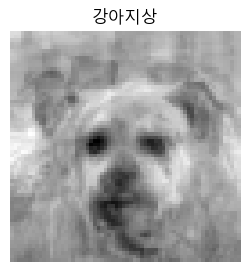

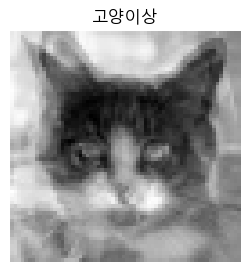

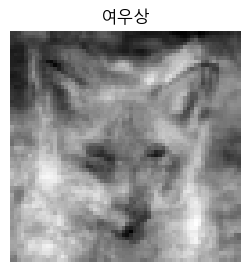

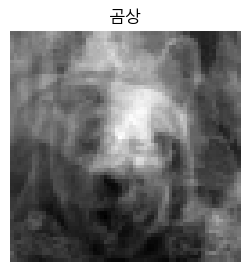

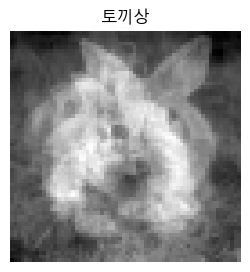


템플릿 매칭 1차 정확도
Accuracy : 0.5000

Confusion Matrix
[[1 0 1 0 0]
 [0 2 0 0 0]
 [0 0 0 0 2]
 [0 1 0 1 0]
 [0 1 0 0 1]]

Classification Report
              precision    recall  f1-score   support

        강아지상       1.00      0.50      0.67         2
        고양이상       0.50      1.00      0.67         2
         여우상       0.00      0.00      0.00         2
          곰상       1.00      0.50      0.67         2
         토끼상       0.33      0.50      0.40         2

    accuracy                           0.50        10
   macro avg       0.57      0.50      0.48        10
weighted avg       0.57      0.50      0.48        10



In [36]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

IMG_SIZE = 64

LABEL_NAME = {
    0: "강아지상",
    1: "고양이상",
    2: "여우상",
    3: "곰상",
    4: "토끼상"
}

DATASET_PATH = Path("./animal_face_dataset.csv")

if not DATASET_PATH.exists():
    raise FileNotFoundError("animal_face_dataset.csv가 없습니다. 먼저 1단계 전처리 셀을 실행하세요.")

df = pd.read_csv(DATASET_PATH)

pixel_cols = [col for col in df.columns if col.startswith("pixel_")]

X = df[pixel_cols].values / 255.0
y = df["Label"].values

existing_labels = sorted(df["Label"].unique())
existing_label_names = [LABEL_NAME[label] for label in existing_labels]

class_counts = pd.Series(y).value_counts()
can_stratify = (class_counts >= 2).all()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if can_stratify else None
)

templates = {}

for label in existing_labels:
    class_images = X_train[y_train == label]
    templates[label] = class_images.mean(axis=0)

for label in existing_labels:
    plt.figure(figsize=(3, 3))
    plt.imshow(
        templates[label].reshape(IMG_SIZE, IMG_SIZE),
        cmap="gray"
    )
    plt.title(LABEL_NAME[label])
    plt.axis("off")
    plt.show()

def predict_template_matching(image, templates):
    """
    입력 이미지와 각 동물상 평균 얼굴 템플릿 사이의
    유클리디안 거리를 계산한 뒤 가장 가까운 라벨을 반환합니다.
    """
    distances = {}

    for label, template in templates.items():
        distance = np.linalg.norm(image - template)
        distances[label] = distance

    pred_label = min(distances, key=distances.get)

    return pred_label, distances


y_pred = []

for image in X_val:
    pred_label, distances = predict_template_matching(image, templates)
    y_pred.append(pred_label)

accuracy = accuracy_score(y_val, y_pred)

print("\n템플릿 매칭 1차 정확도")
print(f"Accuracy : {accuracy:.4f}")

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_val,
        y_pred,
        labels=existing_labels
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_val,
        y_pred,
        labels=existing_labels,
        target_names=existing_label_names,
        zero_division=0
    )
)


In [37]:
df_test = pd.read_csv("./unseen_test_dataset.csv")

X_test = df_test[pixel_cols].values / 255.0
file_names = df_test["Origin_Filename"].values

results = []

for filename, x in zip(file_names, X_test):
    pred_label, distances = predict_template_matching(
    x,
    templates
)

    result = {
        "filename": filename,
        "pred_label": pred_label,
        "pred_animal": LABEL_NAME.get(pred_label, str(pred_label))
    }

    for label, dist in distances.items():
        result[f"distance_{LABEL_NAME.get(label, label)}"] = dist

    results.append(result)

df_result = pd.DataFrame(results)
df_result.to_csv("./template_matching_result.csv", index=False, encoding="utf-8-sig")

df_result.head()


,filename,pred_label,pred_animal,distance_강아지상,distance_고양이상,distance_여우상,distance_곰상,distance_토끼상
0,George_Ryan_0004.jpg,0,강아지상,8.781166,15.905235,11.941075,18.524544,11.251675
1,손영웅01.jpg,4,토끼상,15.433399,19.619652,12.734021,21.627291,12.654497
2,손영웅02.jpg,4,토끼상,21.033300,29.112483,21.499046,30.355604,16.985890


📸 총 3개의 테스트 이미지를 발견했습니다. 중복 없이 분석을 시작합니다!



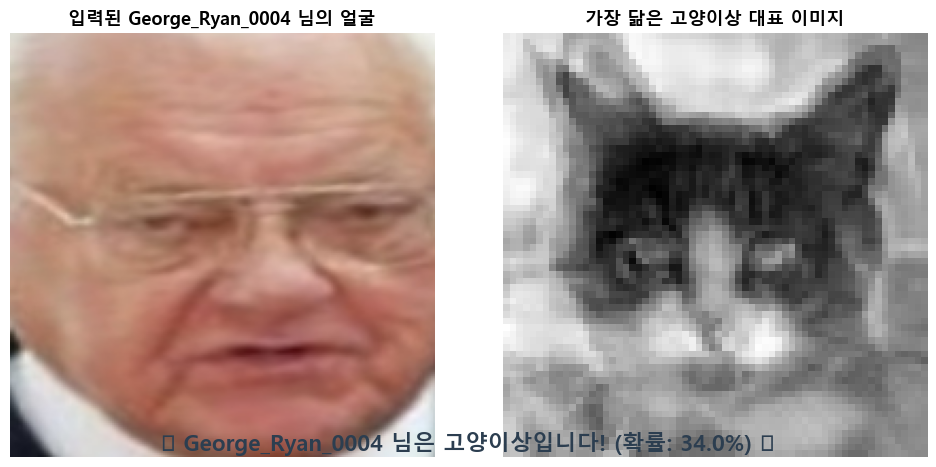

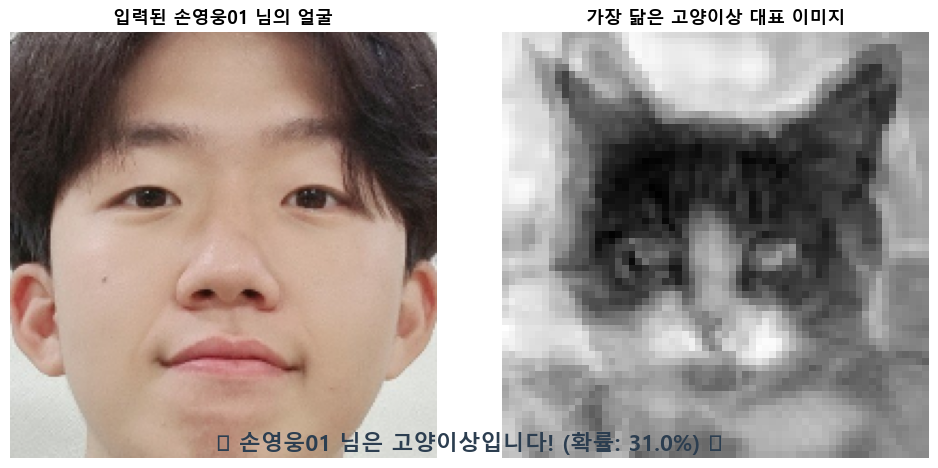

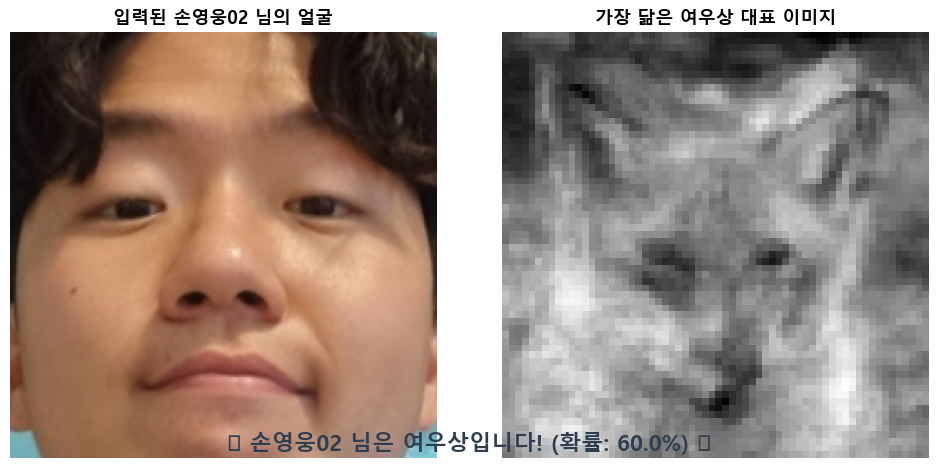

In [38]:
import glob
import os

# 1. 설정 및 준비
label_map = {0: "강아지상", 1: "고양이상", 2: "여우상"}

animal_templates = {}
for label in np.unique(y_train):
    animal_templates[label] = X_train[y_train == label].mean(axis=0)

# 2. 검사할 대상 폴더 경로 설정
test_folder_path = r"D:\Semesters\2026-1(6th semester)\AI 개론\Team Project\test_images"

# 3. 중복 없이 깔끔하게 모든 이미지 파일 가져오기 (대소문자 중복 제거)
# set()을 활용하여 동일한 경로가 두 번 들어가는 현상을 완벽히 차단합니다.
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
image_files_set = set()

for ext in image_extensions:
    # 각 확장자별로 찾은 파일들을 집합(set)에 추가하여 중복을 자동 제거
    image_files_set.update(glob.glob(os.path.join(test_folder_path, ext)))

# 다시 정렬된 리스트로 변환
image_files = sorted(list(image_files_set))

# 4. 발견된 이미지 개수 확인 및 자동 루프 실행
if len(image_files) == 0:
    print(f"❌ [확인 필요] {test_folder_path} 폴더 안에 이미지 파일이 없습니다.")
else:
    print(f"📸 총 {len(image_files)}개의 테스트 이미지를 발견했습니다. 중복 없이 분석을 시작합니다!\n")
    
    for idx, file_path in enumerate(image_files):
        # 파일명만 추출해서 이름으로 사용
        file_name = os.path.basename(file_path)
        user_name_placeholder = os.path.splitext(file_name)[0]
        
        # 함수 호출
        show_animal_face_result(
            image_path=file_path, 
            user_name=user_name_placeholder, 
            model=rf_model, 
            pca=pca, 
            templates=animal_templates, 
            label_mapping=label_map
        )